In [1]:
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx

from feedstock_maintainers.graph_data import build_package_graph

In [2]:
with open("./repodata.noarch.json") as f:
    noarch = json.load(f)

with open("./repodata.linux-64.json") as f:
    linux = json.load(f)

In [3]:
graph = build_package_graph([noarch, linux], previous_versions=3)

In [4]:
def dep_tree(graph: nx.DiGraph, package: str) -> nx.DiGraph:
    """Return the tree of transitive dependencies rooted at `package`.

    Uses nx.dfs_tree, which is cycle-safe (tracks visited nodes internally)
    even though the source dependency graph can contain cycles.
    """
    return nx.dfs_tree(graph, package)


def hierarchy_pos(
    tree: nx.DiGraph,
    root: str,
    width: float = 1.0,
    vert_gap: float = 0.2,
) -> dict[str, tuple[float, float]]:
    """Lay out a tree DiGraph top-down, level by level.

    Positions each node so its children are spread evenly beneath it.
    Avoids needing pygraphviz/pydot for a hierarchical layout.
    """

    def _place(
        node: str,
        left: float,
        right: float,
        vert_loc: float,
        pos: dict[str, tuple[float, float]],
    ) -> None:
        pos[node] = ((left + right) / 2, vert_loc)
        children = list(tree.successors(node))
        if not children:
            return
        step = (right - left) / len(children)
        for i, child in enumerate(children):
            _place(child, left + i * step, left + (i + 1) * step, vert_loc - vert_gap, pos)

    pos: dict[str, tuple[float, float]] = {}
    _place(root, 0.0, width, 0.0, pos)
    return pos


def plot_dep_tree(graph: nx.DiGraph, root: str) -> None:
    """Draw the dependency tree rooted at `root`, color-coded by depth."""
    tree = dep_tree(graph, root)

    depth = nx.shortest_path_length(tree, root)
    max_depth = max(depth.values()) if depth else 0

    cmap = mpl.colormaps["viridis"].resampled(max_depth + 1)
    node_colors = [cmap(depth[node]) for node in tree.nodes]

    pos = hierarchy_pos(tree, root)

    plt.figure(figsize=(12, 8))
    nx.draw(
        tree,
        pos,
        with_labels=True,
        node_color=node_colors,
        node_size=1200,
        font_size=8,
        arrows=True,
    )

    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=cmap(d),
            markersize=10,
            label=f"depth {d}",
        )
        for d in range(max_depth + 1)
    ]
    plt.legend(handles=legend_handles, loc="best", title="Dependency depth")

    plt.title(f"Dependency tree for '{root}'")
    plt.tight_layout()
    plt.show()


def print_ascii_tree(graph: nx.DiGraph, root: str) -> None:
    """Print the dependency tree rooted at `root` as ASCII art, similar to
    the Unix `tree` command."""
    tree = dep_tree(graph, root)

    def _print(node: str, prefix: str, is_last: bool) -> None:
        connector = "└── " if is_last else "├── "
        print(f"{prefix}{connector}{node}")

        child_prefix = prefix + ("    " if is_last else "│   ")
        children = list(tree.successors(node))
        for i, child in enumerate(children):
            _print(child, child_prefix, is_last=i == len(children) - 1)

    print(root)
    children = list(tree.successors(root))
    for i, child in enumerate(children):
        _print(child, "", is_last=i == len(children) - 1)

In [8]:
print(list(graph.successors("python")))
print_ascii_tree(graph, "python")

['bzip2', 'ld_impl_linux-64', 'libffi', 'libgcc-ng', 'libnsl', 'libsqlite', 'libuuid', 'libzlib', 'ncurses', 'openssl', 'readline', 'tk', 'tzdata', 'xz']
python
├── bzip2
│   └── libgcc-ng
│       ├── _libgcc_mutex
│       └── _openmp_mutex
│           ├── libgomp
│           ├── llvm-openmp
│           │   ├── libzlib
│           │   └── zstd
│           │       └── libstdcxx-ng
│           └── __glibc
├── ld_impl_linux-64
├── libffi
│   └── libgcc
│       ├── cloog
│       │   ├── gmp
│       │   └── isl
│       └── mpc
│           └── mpfr
├── libnsl
├── libsqlite
├── libuuid
├── ncurses
├── openssl
│   └── ca-certificates
│       ├── __win
│       └── __unix
├── readline
├── tk
├── tzdata
└── xz
    ├── liblzma
    ├── liblzma-devel
    ├── xz-gpl-tools
    └── xz-tools


/var/folders/y2/1cj89v2s5qdgnn2w5pkgvqr00000gn/T/ipykernel_58855/281139286.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


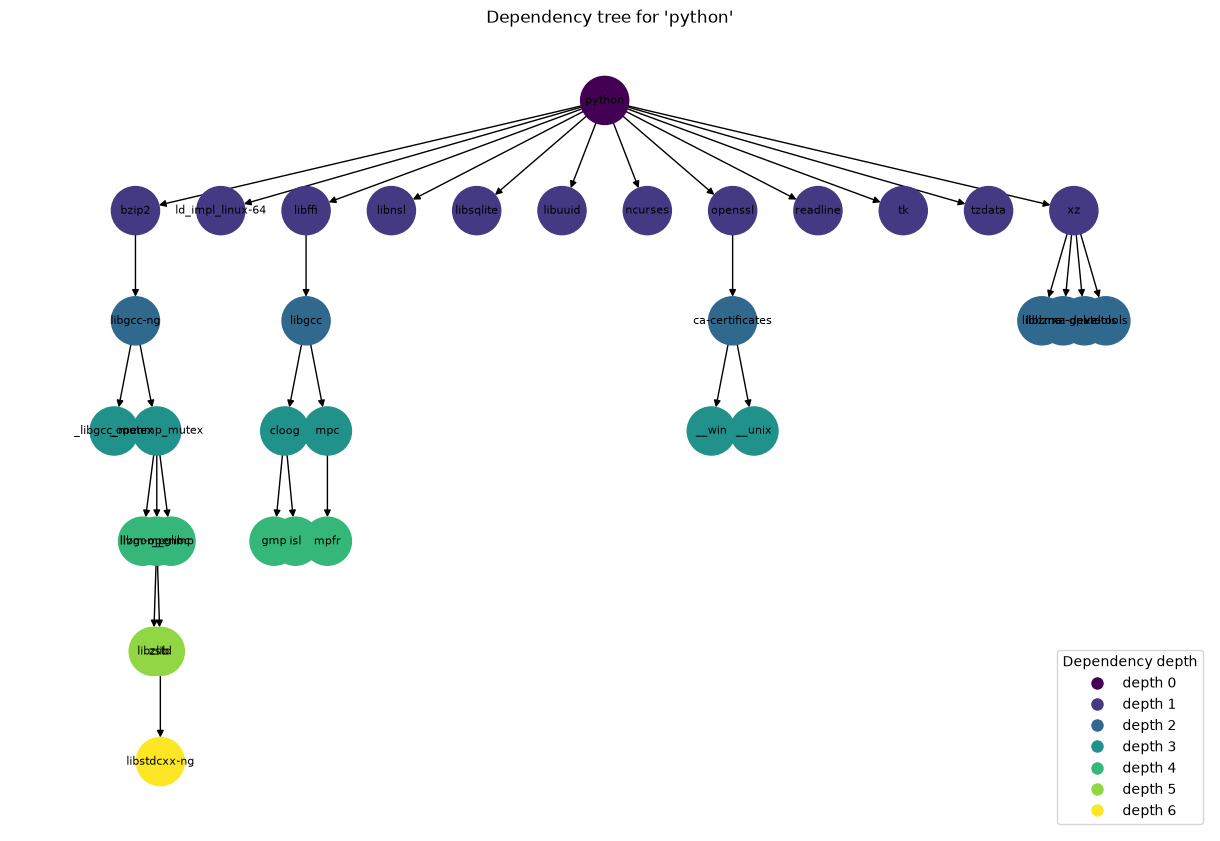

In [6]:
plot_dep_tree(graph, "python")